### Marķēto datu kopu izveidošana

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")  
sys.path.insert(0, PROJECT_ROOT)


from src.visualizations import (
    visualize_paterins,
    visualize_anomalies_over_threshold
)

In [2]:
import pandas as pd
data_csv = os.path.join(PROJECT_ROOT, "data/preprocessed/daily_usage_original.csv")
days_df = pd.read_csv(data_csv)
days_df = days_df.copy()
days_df

,date,delta
0,2024-01-01,0.579900
1,2024-01-02,0.690000
2,2024-01-03,0.670100
3,2024-01-04,0.790000
4,2024-01-05,0.690000
...,...,...
361,2024-12-27,0.621522
362,2024-12-28,0.552853
363,2024-12-29,0.535725
364,2024-12-30,0.627818


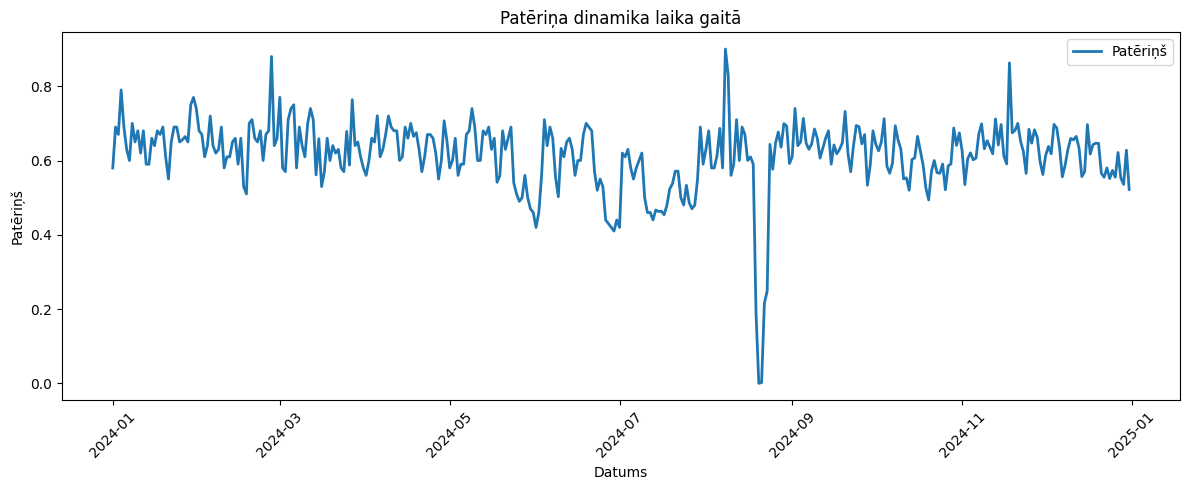

In [3]:
visualize_paterins(days_df)

In [4]:
labeled_df = days_df.copy()
labeled_df["over_threshold"] = labeled_df["delta"] > 0.8

In [5]:
labeled_df

,date,delta,over_threshold
0,2024-01-01,0.579900,False
1,2024-01-02,0.690000,False
2,2024-01-03,0.670100,False
3,2024-01-04,0.790000,False
4,2024-01-05,0.690000,False
...,...,...,...
361,2024-12-27,0.621522,False
362,2024-12-28,0.552853,False
363,2024-12-29,0.535725,False
364,2024-12-30,0.627818,False


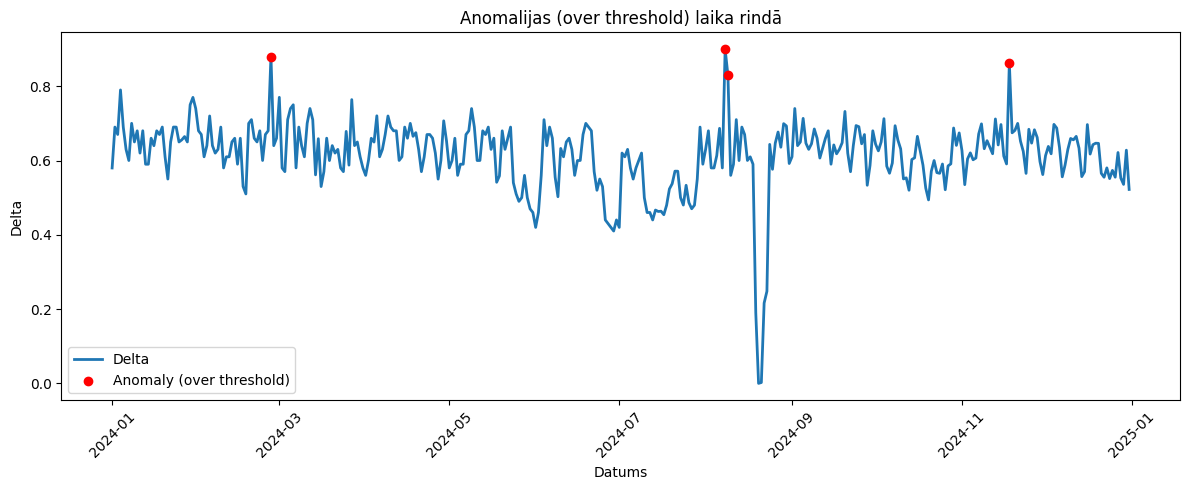

In [6]:
visualize_anomalies_over_threshold(labeled_df)

In [7]:


output_path = os.path.join(PROJECT_ROOT, "data/labeled")
labeled_df.to_csv(os.path.join(output_path, "labeled_df_original.csv"), index=False)

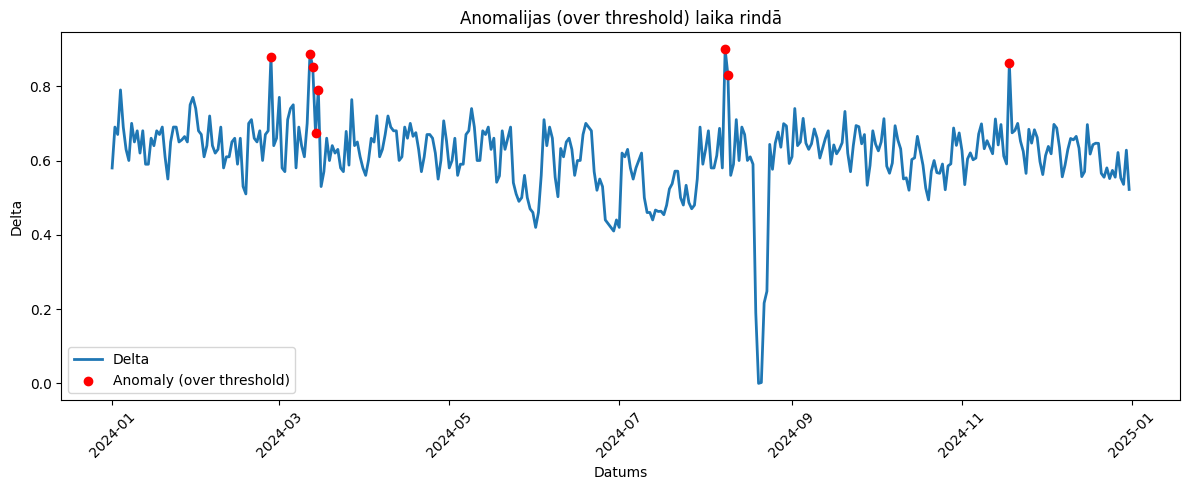

In [8]:
data_csv = os.path.join(PROJECT_ROOT, "data/labeled/labeled_df_leak_march.csv")
leak_df = pd.read_csv(data_csv)
visualize_anomalies_over_threshold(
    leak_df,
    anomaly_column="anomaly"
)

In [24]:
df_no_zero_leak = leak_df[
    (leak_df['delta'] > 0.25) & 
    (leak_df['delta'].notna())
].copy()

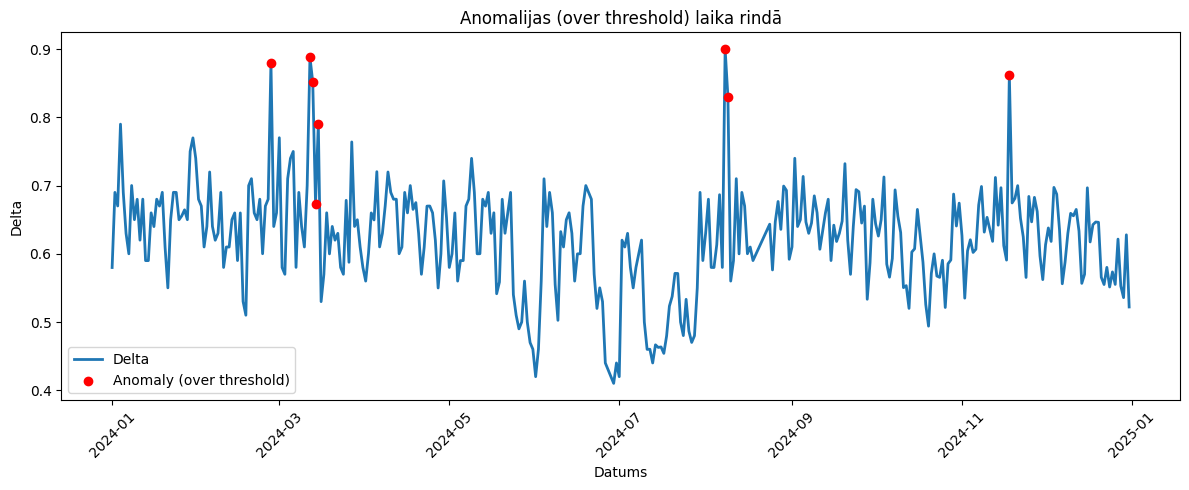

In [25]:
visualize_anomalies_over_threshold(
    df_no_zero_leak,
    anomaly_column="anomaly"
)

In [27]:
output_path = os.path.join(PROJECT_ROOT, "data/labeled")
df_no_zero_leak.to_csv(os.path.join(output_path, "df_no_zero_leak.csv"), index=False)

In [30]:
data_csv = os.path.join(PROJECT_ROOT, "test_outputs/anomaly_labeled_datasets/test1.csv")
leak_df = pd.read_csv(data_csv)


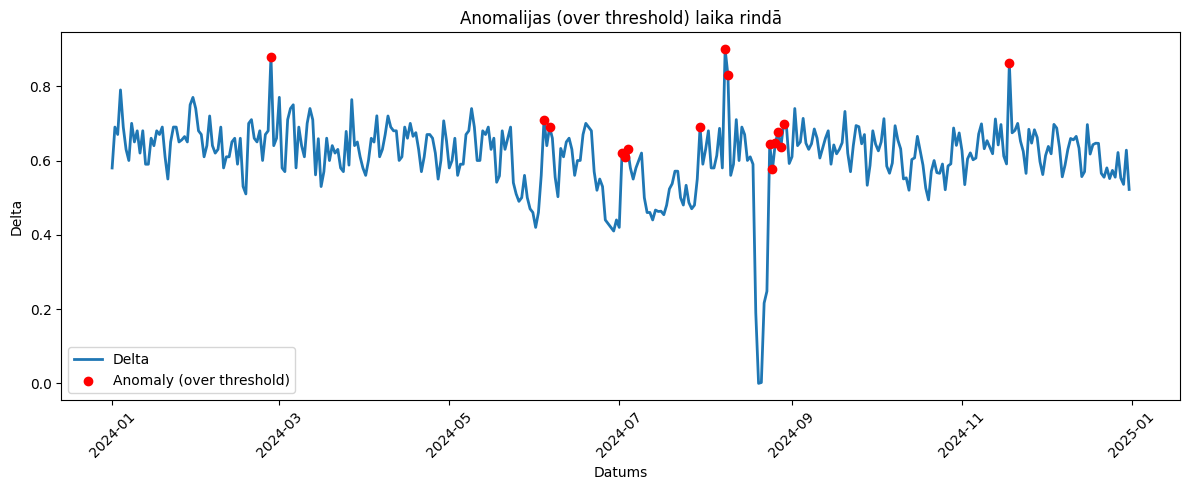

In [31]:
visualize_anomalies_over_threshold(
    leak_df,
    date_column="date",
    value_column="delta",
    anomaly_column="over_threshold"
)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def visualize_dspot_df(
    df: pd.DataFrame,
    title: str = "DSPOT Anomaly Detection",
    save_path: str = None,
    show: bool = True,
    figsize: tuple = (12, 4)
):
    """
    Vizualizē DSPOT rezultātus no DataFrame

    Nepieciešamās kolonnas:
        - date
        - delta
        - threshold
        - over_threshold (True/False)
    """

    required_cols = ["date", "delta", "threshold", "over_threshold"]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Trūkst kolonnas: {missing}")

    plot_df = df.copy()

    plot_df["date"] = pd.to_datetime(plot_df["date"])

    plot_df = plot_df.sort_values("date")

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        plot_df["date"],
        plot_df["delta"],
        label="Delta",
        color=plt.cm.Set1(1),
        lw=1
    )

    ax.plot(
        plot_df["date"],
        plot_df["threshold"],
        label="Threshold",
        color=plt.cm.Set1(0),
        lw=1
    )

    anomalies = plot_df["over_threshold"].astype(bool)

    ax.scatter(
        plot_df.loc[anomalies, "date"],
        plot_df.loc[anomalies, "delta"],
        facecolor="none",
        edgecolor=plt.cm.Set1(0),
        s=30,
        label="Outliers"
    )

    ax.grid(
        axis="both",
        color="black",
        alpha=0.1
    )

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Delta")

    handles, labels = ax.get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.02)
    )

    fig.autofmt_xdate()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figūra saglabāta: {save_path}")

    if show:
        plt.show()
    else:
        plt.close()

In [33]:
leak_df

,date,delta,over_threshold
0,2024-01-01,0.579900,False
1,2024-01-02,0.690000,False
2,2024-01-03,0.670100,False
3,2024-01-04,0.790000,False
4,2024-01-05,0.690000,False
...,...,...,...
361,2024-12-27,0.621522,False
362,2024-12-28,0.552853,False
363,2024-12-29,0.535725,False
364,2024-12-30,0.627818,False


d:\RTU\3.kurss\2.sem\Bakalaura darbs\Anomaly_detection_water\Anomaly_detection_Bakalaura_darbs\src\anomaly_detection_algorithms\pot.py:89: RuntimeWarning: invalid value encountered in scalar divide
  sigma = gamma / candidate


Figūra saglabāta: anomalies.png


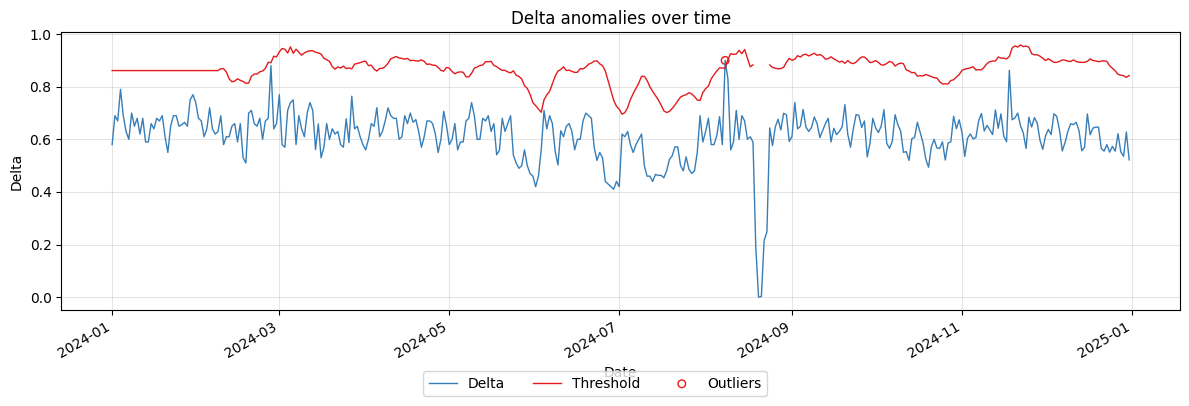

In [ ]:
from src.anomaly_detection_algorithms.dspot import (
    DriftStreamingPeakOverThreshold,
    create_dspot_labeled_dataset
)

from src.visualizations import (
    visualize_dspot,
    visualize_dspot_test
)

from tests.test_params.test1_params import params

import numpy as np
data_csv = os.path.join(PROJECT_ROOT, "test_outputs/anomaly_labeled_datasets/test1.csv")
leak_df = pd.read_csv(data_csv)
mean_value = leak_df["delta"].mean()
std_value = leak_df["delta"].std()
lower_bound = mean_value - 3*std_value
valid_mask = (
    (leak_df['delta'] > lower_bound) &
    (leak_df['delta'].notna())
)

df_no_zero_leak = leak_df[valid_mask].copy()

# DSPOT izmantotie dati
data_filtered = df_no_zero_leak["delta"].to_numpy()

# DSPOT
threshold_array_filtered = DriftStreamingPeakOverThreshold(
    data=data_filtered,
    num_init=params["num_init"],
    depth=params["depth"],
    num_candidates=params["num_candidates"],
    risk=params["risk"],
    init_level=params["init_level"],
    epsilon=params["epsilon"],
)

threshold_array_full = np.full(len(leak_df), np.nan)

threshold_array_full[valid_mask.values] = threshold_array_filtered

leak_df["threshold"] = threshold_array_full

# Anomālijas
leak_df["over_threshold"] = (
    leak_df["threshold"].notna() &
    (leak_df["delta"] > leak_df["threshold"])
)

visualize_dspot_df(
    df=leak_df,
    title="Delta anomalies over time",
    save_path="anomalies.png"
)

In [35]:
threshold

array([0.86153459, 0.86153459, 0.86153459, 0.86153459, 0.86153459,
       0.86153459, 0.86153459, 0.86153459, 0.86153459, 0.86153459,
       0.86153459, 0.86153459, 0.86153459, 0.86153459, 0.86153459,
       0.86153459, 0.86153459, 0.86153459, 0.86153459, 0.86153459,
       0.86153459, 0.86153459, 0.86153459, 0.86153459, 0.86153459,
       0.86153459, 0.86153459, 0.86153459, 0.86153459, 0.86153459,
       0.86153459, 0.86153459, 0.86153459, 0.86153459, 0.86153459,
       0.86153459, 0.86153459, 0.86153459, 0.86153459, 0.86870601,
       0.86870601, 0.85583459, 0.8301203 , 0.81867744, 0.82156316,
       0.8301203 , 0.82440601, 0.82010601, 0.81297744, 0.81408631,
       0.83977172, 0.84834315, 0.84834315, 0.8569003 , 0.85977172,
       0.86977172, 0.89262887, 0.89181026, 0.91608168, 0.91323883,
       0.93267814, 0.94554956, 0.94266385, 0.92837814, 0.95173854,
       0.92711846, 0.94283275, 0.93143275, 0.91998989, 0.92857561,
       0.93428989, 0.93693194, 0.93694622, 0.93121765, 0.92854

In [38]:
leak_df["threshold"] = threshold
leak_df["over_threshold"] = leak_df["delta"] > leak_df["threshold"]

In [39]:
leak_df

,date,delta,over_threshold,threshold
0,2024-01-01,0.579900,False,0.861535
1,2024-01-02,0.690000,False,0.861535
2,2024-01-03,0.670100,False,0.861535
3,2024-01-04,0.790000,False,0.861535
4,2024-01-05,0.690000,False,0.861535
...,...,...,...,...
361,2024-12-27,0.621522,False,0.839956
362,2024-12-28,0.552853,False,0.836441
363,2024-12-29,0.535725,False,0.834631
364,2024-12-30,0.627818,False,0.829560


In [57]:

mean_value

np.float64(0.6142620218579234)

In [59]:
std_value

np.float64(0.09431108784648155)

In [61]:
mean_value - 3*std_value

np.float64(0.3313287583184788)